1. Red Nuronal y sus componentes principales
La red neuronal es un modelo de aprendizaje automatico que sirve para la toma de decisiones similando el cerebro humano, mediante el uso de procesos que imitan las neuronas biológicas trabajando juntas e identificando fenómenos, predicciones y llegar a las conclusiones.
Las redes neuronales se basan en unos datos de entrenamientos que buscan aprender y mejorar precisión con el tiempo. Una vez se logran ajustar podemos decir que son herramientas poderosas y muy valiosas en informatica e inteligencia artificial, permitiendos clasificar y agrupar datos a alta velocidad. Las tareas de reconocimiento de voz o reconocimiento de imagenes se logra disminuir tiempos en minutos en vez de horas si comparamos con la identificacion manual refiriendonos a expertos humanos. Las redes neuronales se denominan como redes neuronales artificiales (ANN) o redes neuronales simuladas (SNN), son el subconjunto de aprendizaje automatico y son la base principal de los modelos de aprendizaje profundo. Se compone de capas de nodos(neuronas) que estabn conectados entre si, transformando entradas en salidas a través de pesos y funciones de activacion
Componentes principales:
Capa de entrada: Recibe los datos
Capa Oculta: Procesa información mediante pesos, signos y funciones de activuación.
Pesos y sesgos: Son los parámetros ajustables que determinan la influencia de cada conexión.
Función de activación: Permite el aprendizaje de patrones completos
2. Qué es el Backpropagation
Es el algoritmo de entrenamiento que ajusta los pesos en la red para minimizar el error, por medio de unas etapas
a) propagación hacia delante
b) calculo del error
c) retropropagación del error
d) actualización de pesos con descenso del gradiante
Permitiendo que la red aprenda y mejore con el tiempo
3. Funciones de Activación Comunes y sus Características

| Función       | Rango de salida | Ventajas clave | Desventajas | Usos típicos |
|---------------|------------------|----------------|-------------|---------------|
| **ReLU**      | [0, ∞)           | Computacionalmente eficiente; evita gradiente desvanecido | Puede causar neuronas muertas | Capas ocultas |
| **Sigmoid**   | (0, 1)           | Interpretable como probabilidad | Saturación, gradientes pequeños | Salida en clasificación binaria |
| **Tanh**      | (-1, 1)          | Salida centrada en 0 | También puede saturarse | Capas ocultas (menos usada hoy) |
| **Leaky ReLU**| (-∞, ∞)          | Evita neuronas muertas | Introduce un parámetro extra | Capas ocultas más estables |
| **Softmax**   | (0, 1), suma = 1 | Distribución de probabilidad en múltiples clases | Sensible a valores extremos | Capa de salida multiclase |


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [5]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


C:\Users\MILENA\.conda\envs\entorno_pandas\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8730 - loss: 0.3988 - val_accuracy: 0.9982 - val_loss: 0.0525
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9983 - loss: 0.0366 - val_accuracy: 0.9985 - val_loss: 0.0135
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9987 - loss: 0.0120 - val_accuracy: 0.9989 - val_loss: 0.0078
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0077 - val_accuracy: 0.9992 - val_loss: 0.0060
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9993 - loss: 0.0055 - val_accuracy: 0.9993 - val_loss: 0.0052
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9993 - loss: 0.0050 - val_accuracy: 0.9993 - val_loss: 0.0047
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0037 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.9993 - val_loss:

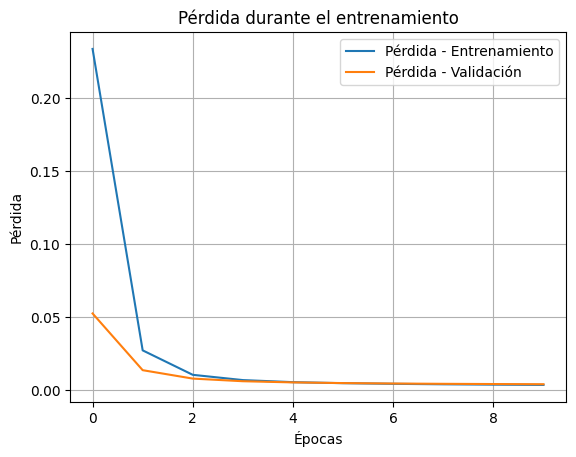

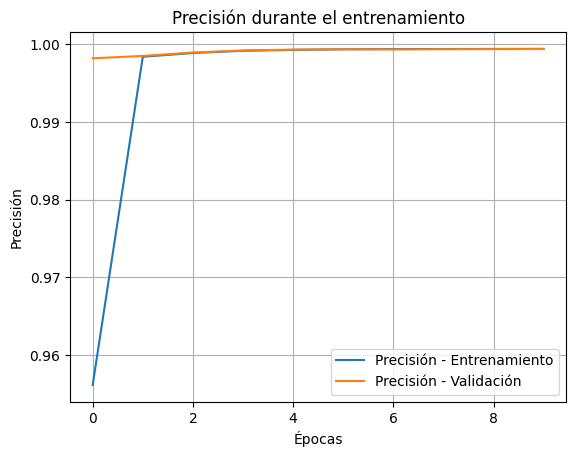

In [20]:

df = pd.read_csv("creditcard.csv")


X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=2048)


loss, accuracy = model.evaluate(X_test, y_test)
print(f"✅ Precisión en test: {accuracy:.4f}")


plt.plot(history.history['loss'], label='Pérdida - Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida - Validación')
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history['accuracy'], label='Precisión - Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión - Validación')
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.show()


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


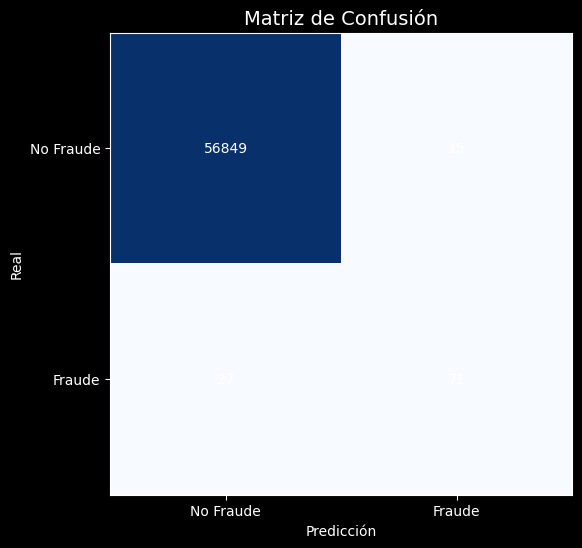

In [33]:

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)


plt.style.use('dark_background')


fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Fraude", "Fraude"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)


ax.set_title("Matriz de Confusión", color='white', fontsize=14)
ax.set_xlabel("Predicción", color='white')
ax.set_ylabel("Real", color='white')


ax.tick_params(colors='white')


for text in disp.text_.ravel():
    text.set_color("white")

plt.grid(False)
plt.show()

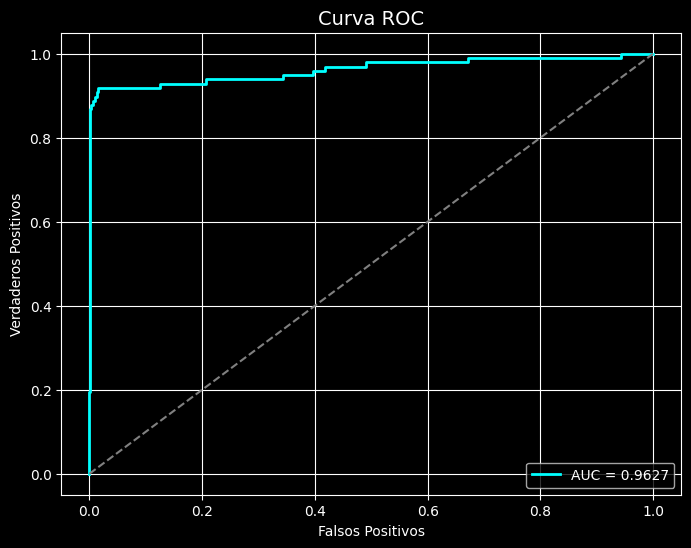

In [31]:

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Fondo negro
plt.style.use('dark_background')
plt.figure(figsize=(8, 6), facecolor='black')
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color='cyan', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("Curva ROC", fontsize=14, color="white")
plt.xlabel("Falsos Positivos", color="white")
plt.ylabel("Verdaderos Positivos", color="white")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
